<a href="https://colab.research.google.com/github/Prasanna-datascience/Data201Class/blob/main/week-02/Week_2_Lab_Intro_to_Python_Prasanna.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1 - Python Warm-Up

                     Unnamed: 0 Private  Apps  Accept  Enroll  Top10perc  \
0  Abilene Christian University     Yes  1660    1232     721         23   
1            Adelphi University     Yes  2186    1924     512         16   
2                Adrian College     Yes  1428    1097     336         22   
3           Agnes Scott College     Yes   417     349     137         60   
4     Alaska Pacific University     Yes   193     146      55         16   

   Top25perc  F.Undergrad  P.Undergrad  Outstate  Room.Board  Books  Personal  \
0         52         2885          537      7440        3300    450      2200   
1         29         2683         1227     12280        6450    750      1500   
2         50         1036           99     11250        3750    400      1165   
3         89          510           63     12960        5450    450       875   
4         44          249          869      7560        4120    800      1500   

   PhD  Terminal  S.F.Ratio  perc.alumni  Expend  Grad.R

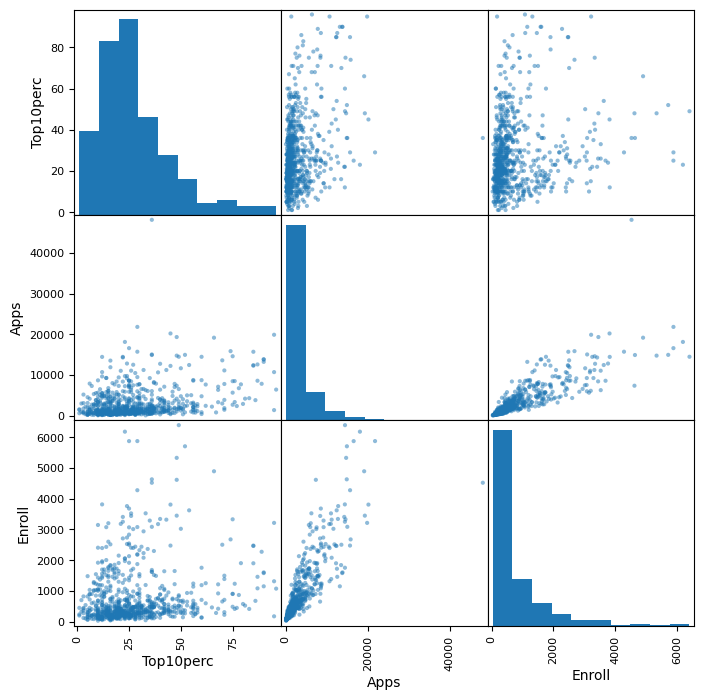

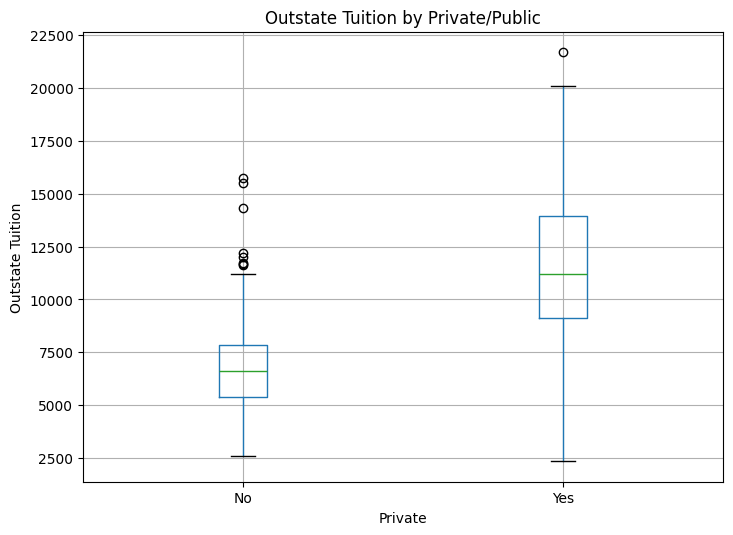

                              Top10perc Elite
Abilene Christian University         23    No
Adelphi University                   16    No
Adrian College                       22    No
Agnes Scott College                  60   Yes
Alaska Pacific University            16    No

Elite Counts:
Elite
No     699
Yes     78
Name: count, dtype: int64


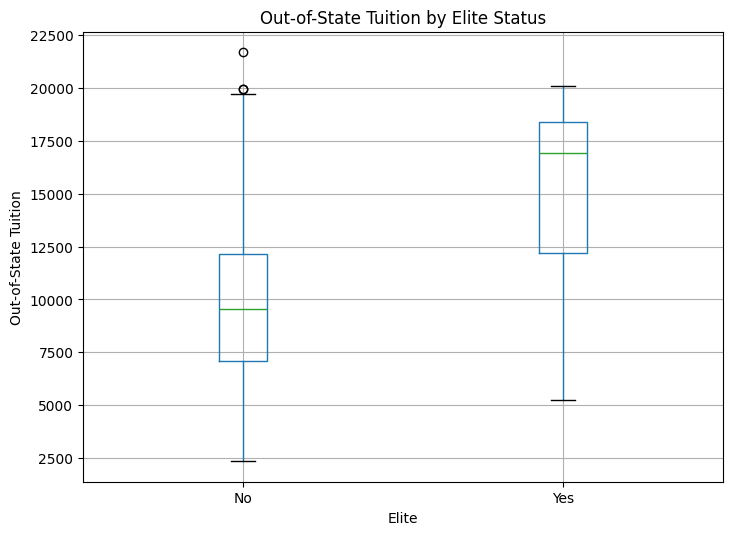

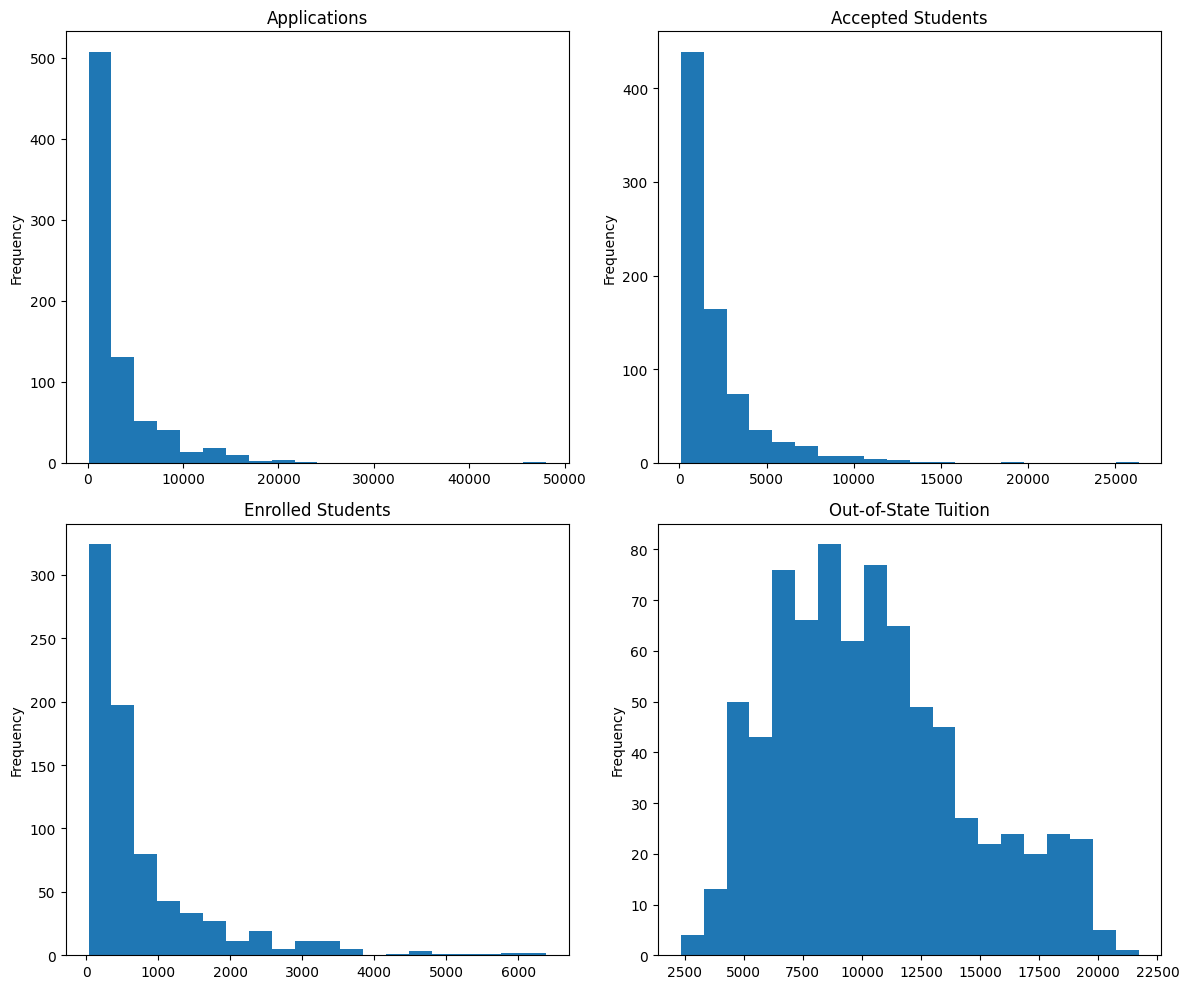

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
# Load dataset from GitHub
url = "https://raw.githubusercontent.com/Reben80/Data201-Fall2026-CRN21732/main/Dataset/College.csv"
college = pd.read_csv(url)

# Display first 5 rows
print(college.head())

# Shape
print("Shape:", college.shape)

# Column names
print("\nColumns:")
print(college.columns)

# Dataset info
print("\nDataset Information:")
college.info()

# ----------------------------------
# (b) Set first column as index
# ----------------------------------
college2 = pd.read_csv(url, index_col=0)
if "Unnamed: 0" in college2.columns:
  college3 = college2.rename(columns={"Unnamed: 0": "College"})
  college3 = college3.set_index("College")
  college = college3
else:
  college = college2
print("\nUpdated DataFrame:")
print(college.head())

# ----------------------------------
# (c) Summary statistics
# ----------------------------------
print("\nSummary Statistics:")
print(college.describe())
# ----------------------------------

# (d) Scatterplot matrix
# ----------------------------------
scatter_matrix(
college[['Top10perc', 'Apps', 'Enroll']],
figsize=(8, 8),
diagonal='hist'
)
plt.show()

# ----------------------------------
# (e) Boxplot
# ----------------------------------
college.boxplot(column='Outstate', by='Private', figsize=(8,6))
plt.title("Outstate Tuition by Private/Public")
plt.suptitle('')
plt.xlabel('Private')
plt.ylabel('Outstate Tuition')
plt.show()

# ----------------------------------
# (f) Create Elite variable
# ----------------------------------
college['Elite'] = pd.cut(
college['Top10perc'],
bins=[0, 50, 100],
labels=['No', 'Yes']
)
# Display the first few rows
print(college[['Top10perc', 'Elite']].head())
# Count the number of Elite and Non-Elite colleges
print("\nElite Counts:")
print(college['Elite'].value_counts())

# Boxplot of Outstate tuition by Elite status
college.boxplot(column='Outstate', by='Elite', figsize=(8, 6))
plt.title('Out-of-State Tuition by Elite Status')
plt.suptitle('') # Removes automatic subtitle
plt.xlabel('Elite')
plt.ylabel('Out-of-State Tuition')
plt.show()


# ----------------------------------
# (g): Histograms of four quantitative variables
# ----------------------------------
# Create a 2x2 grid of histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
college['Apps'].plot.hist(ax=axes[0, 0], bins=20, title='Applications')
college['Accept'].plot.hist(ax=axes[0, 1], bins=20, title='Accepted Students')
college['Enroll'].plot.hist(ax=axes[1, 0], bins=20, title='Enrolled Students')
college['Outstate'].plot.hist(ax=axes[1, 1], bins=20, title='Out-of-State Tuition')
plt.tight_layout()
plt.show()



# The Elite variable separates colleges into two groups based on the percentage of students who graduated in the top 10% of their high school class.
# The boxplot suggests that Elite colleges generally have higher out-of-state tuition than non-Elite colleges.
# The histograms show that variables such as Applications, Acceptances, and Enrollment are right-skewed, indicating that a small number of colleges receive substantially more applications and enroll more students than most colleges.
# Out-of-state tuition also shows considerable variability across institutions.

In [ ]:
#Find the data type
print(type(age))
print(type(student_name))
print(type(passed_midterm))

### Part 2 — NumPy Arrays

In [ ]:
import numpy as np
#NumPy is a Python library for working efficiently with numerical data.

ages = np.array([18, 21, 25, 32, 40])
print(ages)
print(type(ages))


age=(1,2,3)
print(age)
print(type(age))

**Data Types**

* **Tuple:** Heterogeneous. It can store a mix of different data types (strings, numbers, booleans) together.
* **Array:** Homogeneous. Every element must be of the exact same data type.

**Mutability**

* **Tuple:** Immutable. Elements cannot be altered, added, or removed after creation.
* **Array:** Mutable. Individual elements can be modified, though total size is often fixed.

**Common Analogy**

* **Tuple:** Works like a database record or a lightweight struct with fixed positions.
* **Array:** Works like a mathematical vector or a simple inventory list.


In [ ]:
age.mean()

In [ ]:
ages.mean()

In [ ]:
ages.min()

In [ ]:
ages.max()

In [ ]:
income = np.array([30000, 45000, 52000, 75000, 120000])
income.mean()

### Part 3 — Selecting Values

In [ ]:
ages

In [ ]:
#selecting the first value
ages[0]

In [ ]:
#selecting second value to the fourth value
ages[1:4]

In [ ]:
ages[4]

In [ ]:
ages[[1,3]]

In [ ]:
#select the first and the fourth value from 'income'
income[[0,3]]


### Part 4 - Working With a Real Dataset

Upload the Auto dataset to the "Datasets" folder inside your Data_201 folder in Google Drive.

In Google Colab, connect your Google Drive by running:

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the file path

In [ ]:
import pandas as pd
Auto = pd.read_csv("/content/drive/MyDrive/Data_201/Datasets/Auto.csv")

In [ ]:
Auto.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


- What does each row represent?
- What do columns represent?
- Which variables look quantitative?
- Which might actually represent categories?

In [ ]:
Auto.shape

(397, 9)

In [ ]:
Auto["origin"].mean() #does this make sense?

np.float64(1.5743073047858942)

In [ ]:
Auto.columns

### Part 5 — Data Quality and Missing Values

In [ ]:
Auto.isna().sum()

,0
mpg,0
cylinders,0
displacement,0
horsepower,0
weight,0
acceleration,0
year,0
origin,0
name,0


### Part 6 — Selecting Features and Summarizing Data

In [ ]:
Auto["horsepower"]

,horsepower
0,130
1,165
2,150
3,150
4,140
...,...
392,86
393,52
394,84
395,79


In [ ]:
Auto[["horsepower", "mpg"]]

,horsepower,mpg
0,130,18.0
1,165,15.0
2,150,18.0
3,150,16.0
4,140,17.0
...,...,...
392,86,27.0
393,52,44.0
394,84,32.0
395,79,28.0


In [ ]:
cars_small = Auto[["mpg", "horsepower", "weight"]]
cars_small.head()

,mpg,horsepower,weight
0,18.0,130,3504
1,15.0,165,3693
2,18.0,150,3436
3,16.0,150,3433
4,17.0,140,3449


Find the:

- average MPG
- minimum weight

In [ ]:
cars_small["mpg"].mean()

np.float64(23.51586901763224)

In [ ]:
Auto["weight"].min()

1613

In [ ]:
#Now try to find the max of horsepower. What does the result mean?

Auto["horsepower"].max()

'?'

The missing horsepower values are stored as the literal character "?"
Thus, pandas does not automatically recognize them as NaN.

That is why 'Auto.isna().sum()' showed 0!

In [ ]:
cars_small["horsepower"] = cars_small["horsepower"].replace("?", pd.NA)

/tmp/ipykernel_11499/3934517978.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars_small["horsepower"] = cars_small["horsepower"].replace("?", pd.NA)


In [ ]:
#Then convert the column to numeric
cars_small["horsepower"] = pd.to_numeric(cars_small["horsepower"])

/tmp/ipykernel_11499/1029799381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cars_small["horsepower"] = pd.to_numeric(cars_small["horsepower"])


In [ ]:
cars_small["horsepower"].max()

230.0

### Part 7 — One-Hot Encoding


Machine-learning algorithms generally need numeric input. But some numbers in a dataset may actually represent categories rather than quantities.

**For Example**: The origin variable in Auto uses numbers to represent where the vehicle came from.

1 = USA
2 = Europe
3 = Japan

In [ ]:
Auto["origin"].value_counts()

,count
origin,
1,248
3,79
2,70


In [ ]:
#Change the code to meaningful labels
Auto["origin_label"] = Auto["origin"].map({
    1: "USA",
    2: "Europe",
    3: "Japan"
})

In [ ]:
Auto[["origin", "origin_label"]].head()

,origin,origin_label
0,1,USA
1,1,USA
2,1,USA
3,1,USA
4,1,USA


In [ ]:
# Now one-hot encode
pd.get_dummies(Auto["origin_label"], dtype=int)

,Europe,Japan,USA
0,0,0,1
1,0,0,1
2,0,0,1
3,0,0,1
4,0,0,1
...,...,...,...
392,0,0,1
393,1,0,0
394,0,0,1
395,0,0,1


Instead of pretending that USA, Europe, and Japan have a numerical order, Python creates a separate 0/1 variable for each category. Because those numbers are just labels. They do not represent magnitude or order.

### Part 8 — Scaling

In [ ]:
# fixing "horsepower" in Auto
Auto["horsepower"] = Auto["horsepower"].replace("?", pd.NA)
Auto["horsepower"] = pd.to_numeric(Auto["horsepower"])

#check out the ranges. Which feature contains much larger numbers?
Auto[["horsepower", "weight"]].describe()

,horsepower,weight
count,392.000000,397.000000
mean,104.469388,2970.261965
std,38.491160,847.904119
min,46.000000,1613.000000
25%,75.000000,2223.000000
50%,93.500000,2800.000000
75%,126.000000,3609.000000
max,230.000000,5140.000000


For algorithms based on distance, such as KNN, a variable with much larger numbers can dominate the distance calculation.

To avoid data leakage, I would not scale the entire dataset and then split it.

Here is the correct workflow right away.

In [ ]:
from sklearn.model_selection import train_test_split

#We first separate the training data from the test data.
train_data, test_data = train_test_split(
    Auto,
    test_size=0.20,      #allocates 20% of the data to test_data
    random_state=42
)

In [ ]:
# Import StandardScaler to scale numerical features (mean = 0, variance = 1)
from sklearn.preprocessing import StandardScaler

# Choose the numerical features you want to scale
features = ["horsepower", "weight"]

# Instantiate the scaler object
scaler = StandardScaler()

# Fit scaler on training data (calculates mean & std) AND transform it
train_scaled = scaler.fit_transform(train_data[features])

# Transform test data using the parameters learned ONLY from training data
test_scaled = scaler.transform(test_data[features])

Make the Scaling Visible

In [ ]:
train_scaled = pd.DataFrame(
    train_scaled,
    columns=["horsepower_scaled", "weight_scaled"]
)

train_scaled.head()

In [ ]:
train_scaled.describe()

- Are horsepower and weight still measured in their original units?

- Are their numerical scales now much more comparable?

### Part 9 — Quick Visualization

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(Auto["horsepower"], Auto["mpg"])

plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs. MPG")

plt.show()

Describe the relationship in one sentence.